In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime

In [93]:
df = pd.read_csv("C:/Users/karti/Downloads/NFLX.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...,...
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [95]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [96]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


In [97]:
sns.set(rc={'figure.figsize': (10, 5)})

In [98]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
...,...,...,...,...,...,...
2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000


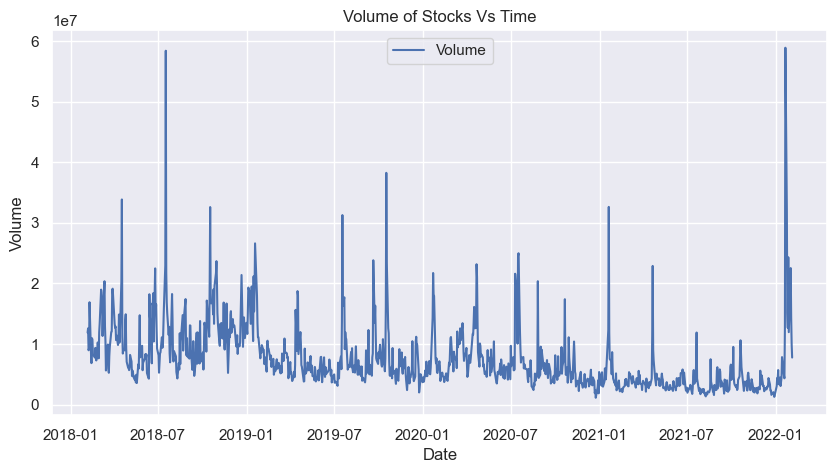

In [99]:
sns.lineplot(x=df.index, y = df['Volume'], label='Volume')
plt.title('Volume of Stocks Vs Time')
plt.show()

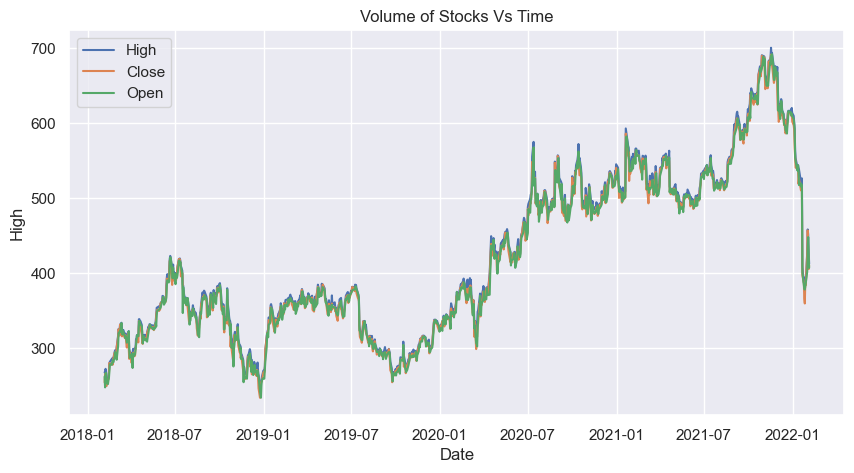

In [100]:
sns.lineplot(x=df.index, y = df['High'], label='High')
sns.lineplot(x=df.index, y = df['Close'], label='Close')
sns.lineplot(x=df.index, y = df['Open'], label='Open')
plt.title('Volume of Stocks Vs Time')
plt.show()

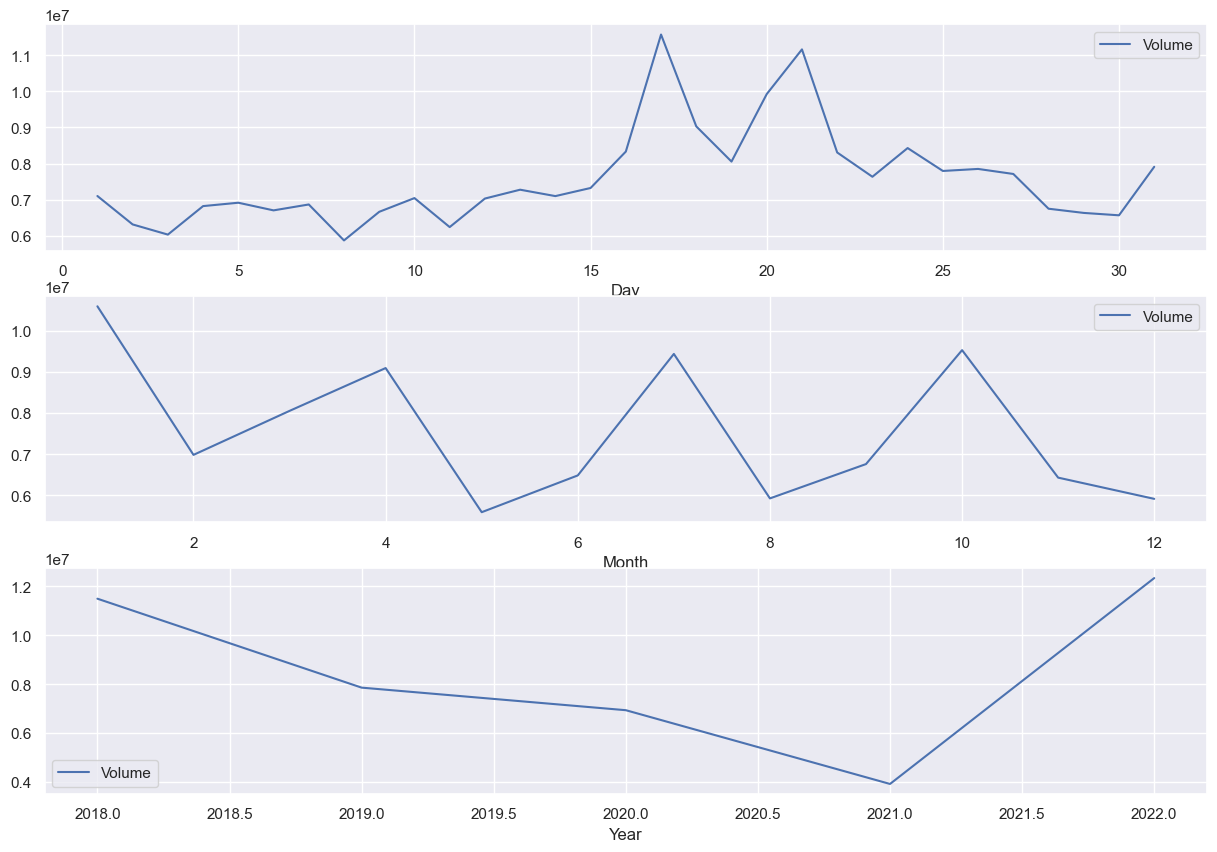

In [101]:
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(15, 10))
df.groupby(df.index.day).mean().plot(y = 'Volume', ax=ax1, xlabel = 'Day')
df.groupby(df.index.month).mean().plot(y = 'Volume', ax=ax2, xlabel = 'Month')
df.groupby(df.index.year).mean().plot(y = 'Volume', ax=ax3, xlabel = 'Year')
plt.show()

# Date with highest stock price

In [102]:
a = df.sort_values(by=['High'], ascending=False).head(5)
a['High']

Date
2021-11-17    700.989990
2021-11-19    694.159973
2021-11-18    691.739990
2021-10-29    690.969971
2021-11-01    689.969971
Name: High, dtype: float64

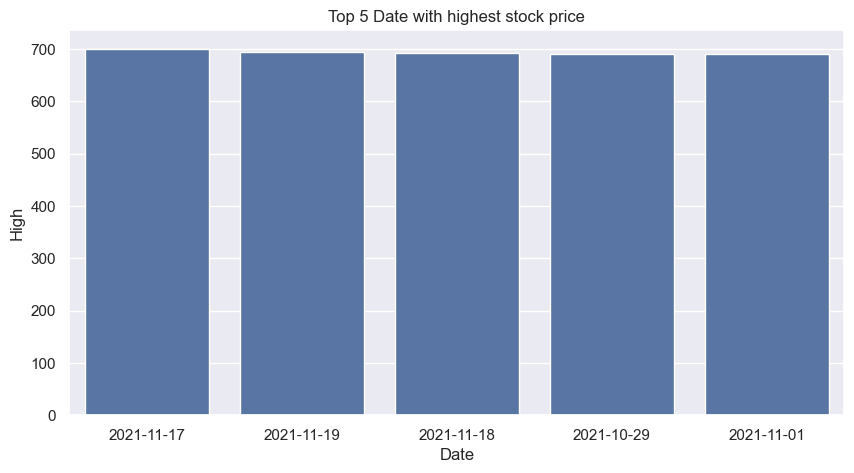

In [103]:
sns.barplot(x=a.index, y = a['High'])
plt.title('Top 5 Date with highest stock price')
plt.show()

# Date with Lowest Stock Price

In [104]:
b = df.sort_values(by=['Low'], ascending=True).head(5)
b['Low']

Date
2018-12-26    231.229996
2018-12-24    233.679993
2018-02-09    236.110001
2018-12-27    240.100006
2018-12-21    241.289993
Name: Low, dtype: float64

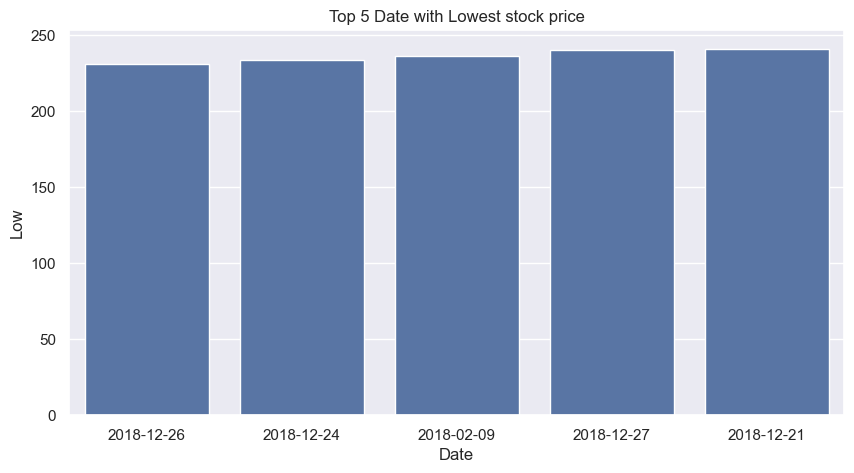

In [105]:
sns.barplot(x=b.index, y = b['Low'])
plt.title('Top 5 Date with Lowest stock price')
plt.show()

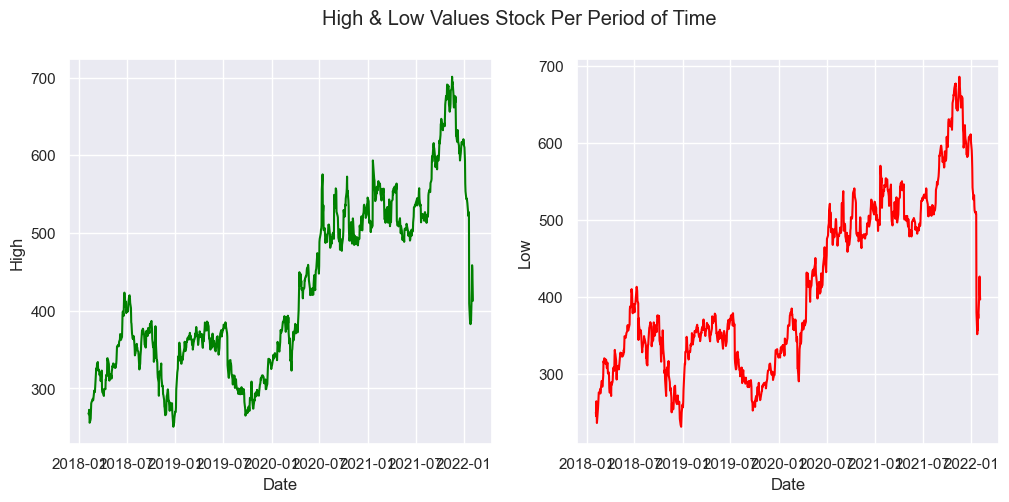

In [106]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, sharex=True, figsize= (12, 5))
fig.suptitle('High & Low Values Stock Per Period of Time')
sns.lineplot(ax=ax1, y = df['High'], x = df.index, color='green')
sns.lineplot(ax=ax2, y = df['Low'], x = df.index, color='red')
plt.show()

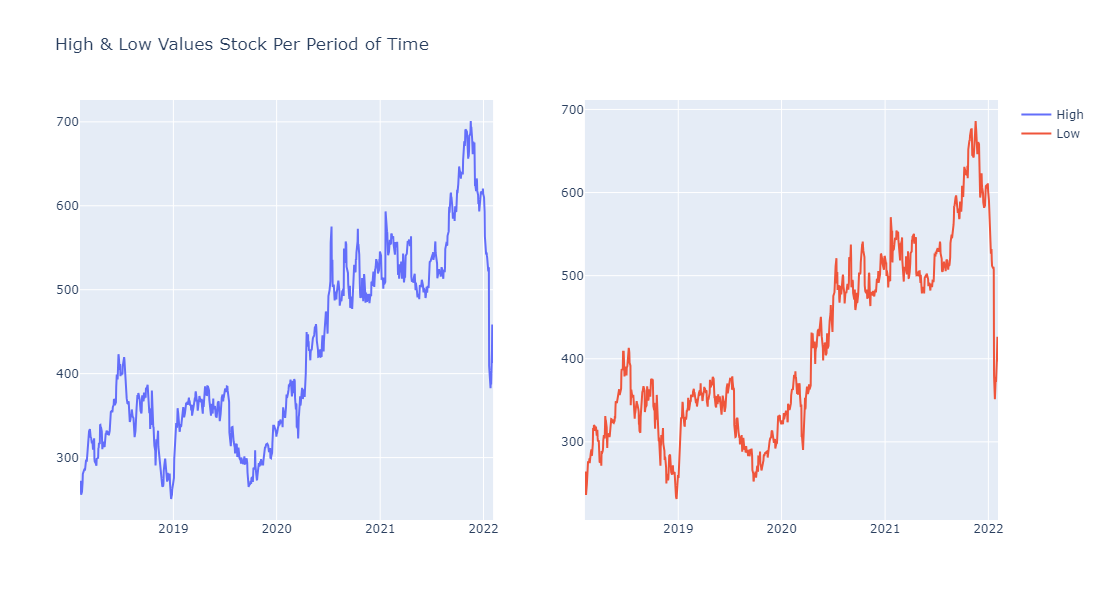

In [112]:
fig = make_subplots(rows=1, cols=2)
fig.add_trace(
    go.Scatter(x=df.index, y=df.High, name='High'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df.index, y=df.Low, name='Low'),
    row=1, col=2
)

fig.update_layout(height=600, width=1000, title_text = 'High & Low Values Stock Per Period of Time')
fig.show()